In [2]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\DELL\AppData\Local\Temp\MicrosoftEdgeDownloads\c245dd27-57b7-4661-a456-f0b9ae5444cd\dataset.csv"
)

df.head()


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


Dataset Shape: (1461, 6)

Columns: Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


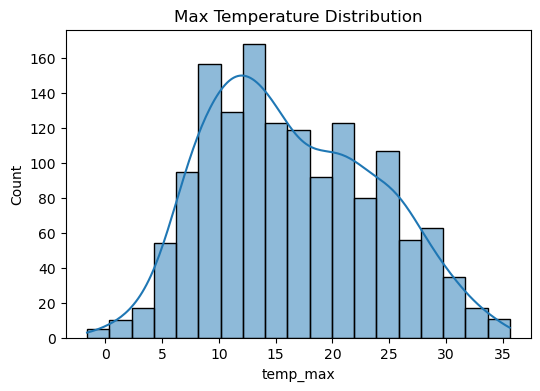

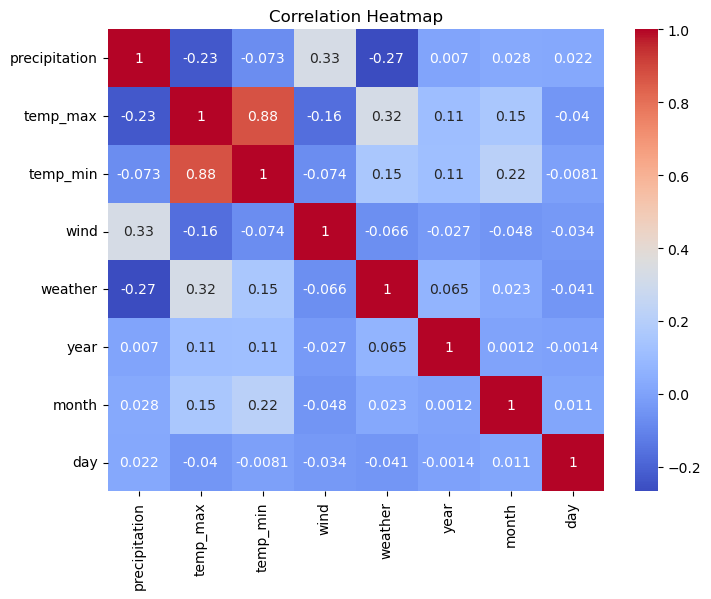

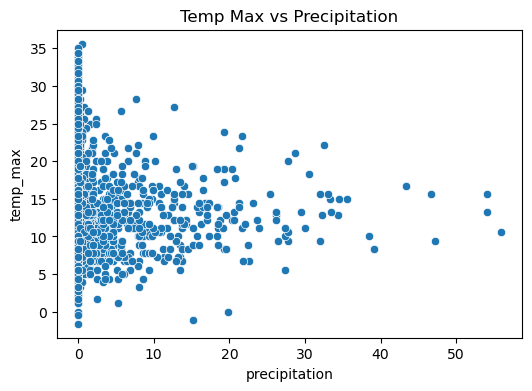

In [7]:
# ======================================
# WEATHER PREDICTION MINOR PROJECT
# DATASET-BASED COMPLETE CODE
# ======================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load Dataset 
df = pd.read_csv(
    r"C:\Users\DELL\AppData\Local\Temp\MicrosoftEdgeDownloads\c245dd27-57b7-4661-a456-f0b9ae5444cd\dataset.csv"
)

# 3. Basic Info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
df.info()

# 4. Convert Date column
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.drop('date', axis=1, inplace=True)

# 5. Encode Weather (Categorical → Numeric)
le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])

# 6. Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# ================= EDA =================

# Max Temperature Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['temp_max'], kde=True)
plt.title("Max Temperature Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Temp vs Precipitation
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['precipitation'], y=df['temp_max'])
plt.title("Temp Max vs Precipitation")
plt.show()

# ================= ML MODEL =================

# 7. Feature Selection
X = df[['precipitation', 'temp_min', 'wind', 'weather', 'year', 'month', 'day']]
y = df['temp_max']

# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 9. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
